In [29]:
import subprocess
import sys

def pip_show_version(package):
    try:
        output = subprocess.check_output(
            [sys.executable, "-m", "pip", "show", package],
            text=True
        )
    except subprocess.CalledProcessError:
        return None
    for line in output.splitlines():
        if line.lower().startswith("version:"):
            return line.split(":", 1)[1].strip()
    return None

torch_version = pip_show_version("torch")
torchvision_version = pip_show_version("torchvision")
torchaudio_version = pip_show_version("torchaudio")

print("Detected torch       :", torch_version)
print("Detected torchvision :", torchvision_version)
print("Detected torchaudio  :", torchaudio_version)

if torch_version is not None:
    base_torch = torch_version.split("+")[0]
    base_torchvision = torchvision_version.split("+")[0] if torchvision_version else None
    base_torchaudio = torchaudio_version.split("+")[0] if torchaudio_version else None

    reinstall_packages = [f"torch=={base_torch}"]
    if base_torchvision:
        reinstall_packages.append(f"torchvision=={base_torchvision}")
    if base_torchaudio:
        reinstall_packages.append(f"torchaudio=={base_torchaudio}")

    print("Reinstalling for Pascal (sm_60) GPU support:", reinstall_packages)

    subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q",
            "--no-deps", "--force-reinstall",
            *reinstall_packages,
            "--index-url", "https://download.pytorch.org/whl/cu126"
        ],
        check=True
    )

subprocess.run(
    [
        sys.executable, "-m", "pip", "install", "-q", "--no-deps",
        "timm", "albumentations", "opencv-python-headless", "kagglehub"
    ],
    check=True
)

print("Dependency fix complete")

KeyboardInterrupt: 

In [ ]:
import sys
import torch
import numpy as np
import pandas as pd

print("Python        :", sys.version)
print("PyTorch       :", torch.__version__)
print("Torch CUDA    :", torch.version.cuda)
print("NumPy         :", np.__version__)
print("Pandas        :", pd.__version__)

assert torch.cuda.is_available(), "GPU is required for this training pipeline."

print("GPU           :", torch.cuda.get_device_name(0))
print("Capability    :", torch.cuda.get_device_capability(0))
print("VRAM          :", f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
print("Architectures :", torch.cuda.get_arch_list())

test_tensor = torch.randn(4, 4, device="cuda")
test_result = test_tensor @ test_tensor
torch.cuda.synchronize()

print("CUDA kernel execution confirmed:", tuple(test_result.shape))

del test_tensor, test_result
torch.cuda.empty_cache()

In [ ]:
from pathlib import Path
import kagglehub

DATASET_ID = "utkarshsaxenadn/svamitva-drone-aerial-images"
DATA_ROOT = Path(kagglehub.dataset_download(DATASET_ID))

print("Dataset downloaded to:")
print(DATA_ROOT)

In [ ]:
def find_directory_by_name(root, target_names):
    target_names = {x.lower() for x in target_names}
    matches = []
    for p in root.rglob("*"):
        if p.is_dir() and p.name.lower() in target_names:
            matches.append(p)
    return matches

image_dirs = find_directory_by_name(DATA_ROOT, {"images"})
mask_dirs = find_directory_by_name(
    DATA_ROOT,
    {"binarymasks", "binary_masks", "binarymask"}
)

print("Image directories found:")
for p in image_dirs:
    print(" ", p)

print("Mask directories found:")
for p in mask_dirs:
    print(" ", p)

assert len(image_dirs) > 0, "Could not find an Images directory in the dataset."
assert len(mask_dirs) > 0, "Could not find a BinaryMasks directory in the dataset."

IMAGE_DIR = image_dirs[0]
MASK_DIR = mask_dirs[0]

print("Selected IMAGE_DIR:", IMAGE_DIR)
print("Selected MASK_DIR :", MASK_DIR)

In [ ]:
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".tif", ".tiff"}

def get_stem(path):
    return Path(path).stem.lower()

image_files = sorted([
    p for p in IMAGE_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
])

mask_files = sorted([
    p for p in MASK_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
])

image_map = {get_stem(p): p for p in image_files}
mask_map = {get_stem(p): p for p in mask_files}

common_ids = sorted(set(image_map.keys()) & set(mask_map.keys()))

df = pd.DataFrame({
    "id": common_ids,
    "image": [str(image_map[x]) for x in common_ids],
    "mask": [str(mask_map[x]) for x in common_ids],
})

print("Images        :", len(image_map))
print("Masks         :", len(mask_map))
print("Matched pairs :", len(common_ids))

assert len(common_ids) > 0, "No image/mask pairs found."

display(df.head(10))

In [ ]:
from PIL import Image
from collections import Counter

image_sizes = []
mask_sizes = []
bad_pairs = []

for _, row in df.iterrows():
    try:
        with Image.open(row["image"]) as im:
            img_size = im.size
        with Image.open(row["mask"]) as m:
            mask_size = m.size

        image_sizes.append(img_size)
        mask_sizes.append(mask_size)

        if img_size != mask_size:
            bad_pairs.append((row["id"], img_size, mask_size))

    except Exception as e:
        bad_pairs.append((row["id"], str(e), str(e)))

print("Image sizes:", Counter(image_sizes).most_common(10))
print("Mask sizes :", Counter(mask_sizes).most_common(10))
print("Mismatched pairs:", len(bad_pairs))

if bad_pairs:
    display(pd.DataFrame(bad_pairs, columns=["id", "image_size", "mask_size"]).head(20))

assert len(bad_pairs) == 0, "Some image/mask pairs have incompatible dimensions."

In [ ]:
sample_ids = min(100, len(df))
all_values = set()

for _, row in df.head(sample_ids).iterrows():
    mask = np.array(Image.open(row["mask"]).convert("L"))
    all_values.update(np.unique(mask).tolist())

print("Unique mask values in first", sample_ids, "masks:", sorted(all_values))

positive_pixels = []
positive_ratios = []

for _, row in df.iterrows():
    mask = np.array(Image.open(row["mask"]).convert("L"))
    binary = mask > 0
    positive_pixels.append(int(binary.sum()))
    positive_ratios.append(binary.sum() / binary.size)

df["positive_pixels"] = positive_pixels
df["positive_ratio"] = positive_ratios
df["has_building"] = df["positive_pixels"] > 0

print(f"Mean building ratio   : {df.positive_ratio.mean():.4%}")
print(f"Median building ratio : {df.positive_ratio.median():.4%}")
print(f"Images with buildings : {int(df.has_building.sum())}")
print(f"Empty masks           : {int((~df.has_building).sum())}")

display(df["positive_ratio"].describe())

In [ ]:
import matplotlib.pyplot as plt
import cv2
import random

random.seed(42)
indices = random.sample(range(len(df)), min(6, len(df)))

fig, axes = plt.subplots(len(indices), 3, figsize=(15, 5 * len(indices)))
if len(indices) == 1:
    axes = np.expand_dims(axes, axis=0)

for r, idx in enumerate(indices):
    row = df.iloc[idx]

    image = cv2.imread(row["image"])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(row["mask"], cv2.IMREAD_GRAYSCALE)

    axes[r, 0].imshow(image)
    axes[r, 0].set_title(f"Image — {row['id']}")

    axes[r, 1].imshow(mask, cmap="gray")
    axes[r, 1].set_title("Building Mask")

    axes[r, 2].imshow(image)
    axes[r, 2].imshow(mask > 0, alpha=0.35)
    axes[r, 2].set_title("Overlay")

    for c in range(3):
        axes[r, c].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

df["patch_number"] = df["id"].str.extract(r"(\d+)").astype(int)

original_df = df[df["patch_number"] <= 482].copy()

print("Total original patches:", len(original_df))
print("Total dataset files   :", len(df))

assert len(original_df) > 0

train_df, temp_df = train_test_split(
    original_df,
    test_size=0.20,
    random_state=42,
    stratify=original_df["has_building"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["has_building"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

In [ ]:
OUTPUT_ROOT = Path("/kaggle/working/SVAMITVA_HRNetW48_OCR")

CHECKPOINT_DIR = OUTPUT_ROOT / "checkpoints"
RESULT_DIR = OUTPUT_ROOT / "results"
PRED_DIR = OUTPUT_ROOT / "predictions"
LOG_DIR = OUTPUT_ROOT / "logs"

for p in [OUTPUT_ROOT, CHECKPOINT_DIR, RESULT_DIR, PRED_DIR, LOG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(OUTPUT_ROOT)

In [ ]:
import os
import json
import time
import random

import torch.nn as nn
import torch.nn.functional as F

from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader

import timm
import albumentations as A

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert DEVICE.type == "cuda", "GPU is required for this training pipeline."

USE_AMP = True
USE_CHANNELS_LAST = False

torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

print("Device        :", DEVICE)
print("GPU           :", torch.cuda.get_device_name(0))
print("AMP enabled   :", USE_AMP)
print("channels_last :", USE_CHANNELS_LAST)

In [ ]:
class SvamitvaDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = cv2.imread(row["image"], cv2.IMREAD_COLOR)
        if image is None:
            raise RuntimeError(f"Could not read image: {row['image']}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(row["mask"], cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise RuntimeError(f"Could not read mask: {row['mask']}")
        mask = (mask > 0).astype(np.uint8)

        if self.transform is not None:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]

        image = image.astype(np.float32) / 255.0
        image = torch.from_numpy(image.transpose(2, 0, 1))

        mean = torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(3, 1, 1)
        image = (image - mean) / std

        mask = torch.from_numpy(mask.astype(np.float32)).unsqueeze(0)

        return {"image": image, "mask": mask, "id": row["id"]}

print("SvamitvaDataset defined")

In [ ]:
TRAIN_TRANSFORM_512 = A.Compose([
    A.RandomCrop(height=512, width=512, p=0.45),
    A.Resize(
        height=512, width=512,
        interpolation=cv2.INTER_LINEAR,
        mask_interpolation=cv2.INTER_NEAREST
    ),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(
        scale=(0.90, 1.10),
        translate_percent=(-0.05, 0.05),
        rotate=(-15, 15),
        shear=(-5, 5),
        interpolation=cv2.INTER_LINEAR,
        mask_interpolation=cv2.INTER_NEAREST,
        p=0.35
    ),
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15),
        A.CLAHE(clip_limit=2.0),
        A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=12, val_shift_limit=10)
    ], p=0.30)
])

VAL_TRANSFORM_512 = A.Compose([
    A.Resize(
        height=512, width=512,
        interpolation=cv2.INTER_LINEAR,
        mask_interpolation=cv2.INTER_NEAREST
    )
])

print("TRAIN_TRANSFORM_512 created")
print("VAL_TRANSFORM_512 created")

In [ ]:
train_dataset = SvamitvaDataset(dataframe=train_df, transform=TRAIN_TRANSFORM_512)
val_dataset = SvamitvaDataset(dataframe=val_df, transform=VAL_TRANSFORM_512)
test_dataset = SvamitvaDataset(dataframe=test_df, transform=VAL_TRANSFORM_512)

print("Train samples:", len(train_dataset))
print("Val samples  :", len(val_dataset))
print("Test samples :", len(test_dataset))

sample = train_dataset[0]

print("Image shape :", sample["image"].shape)
print("Mask shape  :", sample["mask"].shape)

assert sample["image"].shape == (3, 512, 512)
assert sample["mask"].shape == (1, 512, 512)
assert set(torch.unique(sample["mask"]).tolist()).issubset({0.0, 1.0})

print("Dataset is working correctly")

In [ ]:
NUM_WORKERS = min(4, os.cpu_count() or 1)
BATCH_SIZE_512 = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE_512,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    prefetch_factor=2 if NUM_WORKERS > 0 else None,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE_512,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    prefetch_factor=2 if NUM_WORKERS > 0 else None
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE_512,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    prefetch_factor=2 if NUM_WORKERS > 0 else None
)

print("Workers :", NUM_WORKERS)
print("Batch   :", BATCH_SIZE_512)
print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

batch = next(iter(train_loader))

print("Images:", batch["image"].shape)
print("Masks :", batch["mask"].shape)
print("IDs   :", batch["id"][:4])

assert batch["image"].shape[1:] == (3, 512, 512)
assert batch["mask"].shape[1:] == (1, 512, 512)

print("DataLoader working correctly")

In [ ]:
class ConvBNReLU(nn.Module):

    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class SpatialGatherModule(nn.Module):

    def __init__(self, cls_num, scale=1):
        super().__init__()
        self.cls_num = cls_num
        self.scale = scale

    def forward(self, feats, probs):
        batch_size = feats.size(0)
        channels = feats.size(1)

        feats = feats.reshape(batch_size, channels, -1)
        probs = probs.reshape(batch_size, self.cls_num, -1)
        feats = feats.permute(0, 2, 1)

        probs = F.softmax(self.scale * probs, dim=2)
        context = torch.matmul(probs, feats)
        context = context.permute(0, 2, 1).contiguous()

        return context.unsqueeze(3)


class ObjectAttentionBlock2D(nn.Module):

    def __init__(self, in_channels, key_channels):
        super().__init__()
        self.key_channels = key_channels

        self.f_pixel = nn.Sequential(
            nn.Conv2d(in_channels, key_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(key_channels),
            nn.ReLU(inplace=True)
        )

        self.f_object = nn.Sequential(
            nn.Conv2d(in_channels, key_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(key_channels),
            nn.ReLU(inplace=True)
        )

        self.f_down = nn.Sequential(
            nn.Conv2d(in_channels, key_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(key_channels),
            nn.ReLU(inplace=True)
        )

        self.f_up = nn.Sequential(
            nn.Conv2d(key_channels, in_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, proxy):
        batch_size = x.size(0)

        query = self.f_pixel(x)
        query = query.reshape(batch_size, self.key_channels, -1)
        query = query.permute(0, 2, 1)

        key = self.f_object(proxy)
        key = key.reshape(batch_size, self.key_channels, -1)

        value = self.f_down(proxy)
        value = value.reshape(batch_size, self.key_channels, -1)

        sim_map = torch.matmul(query, key)
        sim_map = sim_map * (self.key_channels ** -0.5)
        sim_map = F.softmax(sim_map, dim=-1)

        context = torch.matmul(sim_map, value.permute(0, 2, 1))
        context = context.permute(0, 2, 1).contiguous()
        context = context.reshape(batch_size, self.key_channels, x.size(2), x.size(3))

        context = self.f_up(context)

        return context


class SpatialOCRModule(nn.Module):

    def __init__(self, in_channels, key_channels, out_channels):
        super().__init__()
        self.object_context_block = ObjectAttentionBlock2D(in_channels, key_channels)

        self.conv_bn_dropout = nn.Sequential(
            nn.Conv2d(in_channels * 2, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.05)
        )

    def forward(self, feats, proxy):
        object_context = self.object_context_block(feats, proxy)
        output = torch.cat([feats, object_context], dim=1)
        output = self.conv_bn_dropout(output)
        return output


print("OCR modules defined")

In [ ]:
class HRNetW48OCR(nn.Module):

    def __init__(self, num_classes=2, ocr_channels=512, key_channels=256):
        super().__init__()

        self.backbone = timm.create_model(
            "hrnet_w48.ms_in1k",
            pretrained=True,
            features_only=True
        )

        channels = self.backbone.feature_info.channels()
        self.backbone_channels = channels
        self.fused_input_channels = sum(channels)

        print("Backbone feature channels:", channels)
        print("Total fusion channels:", self.fused_input_channels)

        self.fuse = nn.Sequential(
            nn.Conv2d(self.fused_input_channels, ocr_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(ocr_channels),
            nn.ReLU(inplace=True)
        )

        self.aux_head = nn.Sequential(
            ConvBNReLU(ocr_channels, ocr_channels // 2),
            nn.Dropout2d(0.10),
            nn.Conv2d(ocr_channels // 2, num_classes, kernel_size=1)
        )

        self.gather = SpatialGatherModule(num_classes)

        self.ocr = SpatialOCRModule(
            in_channels=ocr_channels,
            key_channels=key_channels,
            out_channels=ocr_channels
        )

        self.cls_head = nn.Sequential(
            ConvBNReLU(ocr_channels, ocr_channels),
            nn.Dropout2d(0.10),
            nn.Conv2d(ocr_channels, num_classes, kernel_size=1)
        )

    def forward(self, x):
        input_size = x.shape[-2:]

        features = self.backbone(x)
        target_size = features[0].shape[-2:]

        resized_features = []
        for feature in features:
            if feature.shape[-2:] != target_size:
                feature = F.interpolate(feature, size=target_size, mode="bilinear", align_corners=False)
            resized_features.append(feature)

        fused = torch.cat(resized_features, dim=1)
        fused = self.fuse(fused)

        aux_logits = self.aux_head(fused)

        context = self.gather(fused, aux_logits)
        ocr_features = self.ocr(fused, context)

        logits = self.cls_head(ocr_features)

        logits = F.interpolate(logits, size=input_size, mode="bilinear", align_corners=False)
        aux_logits = F.interpolate(aux_logits, size=input_size, mode="bilinear", align_corners=False)

        return logits, aux_logits


print("HRNet-W48 + OCR model defined")

In [ ]:
print("Creating HRNet-W48 + OCR...")

model = HRNetW48OCR(num_classes=2, ocr_channels=512, key_channels=256)
model = model.to(DEVICE)

if USE_CHANNELS_LAST:
    model = model.to(memory_format=torch.channels_last)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters     : {total_params / 1e6:.2f}M")
print(f"Trainable parameters : {trainable_params / 1e6:.2f}M")
print("Model successfully moved to", DEVICE)

In [ ]:
model.eval()

dummy = torch.randn(1, 3, 512, 512, device=DEVICE)

with torch.inference_mode():
    with torch.amp.autocast("cuda", enabled=USE_AMP, dtype=torch.float16):
        main_logits, aux_logits = model(dummy)

print("Main logits:", tuple(main_logits.shape))
print("Aux logits :", tuple(aux_logits.shape))

assert main_logits.shape == (1, 2, 512, 512), f"Unexpected main output: {main_logits.shape}"
assert aux_logits.shape == (1, 2, 512, 512), f"Unexpected auxiliary output: {aux_logits.shape}"

print("Full model forward pass successful")

del dummy, main_logits, aux_logits
torch.cuda.empty_cache()

In [ ]:
train_positive_ratio = float(train_df["has_building"].mean())

building_weight = ((1.0 - train_positive_ratio) / max(train_positive_ratio, 1e-6)) ** 0.5
building_weight = float(np.clip(building_weight, 1.5, 6.0))

class_weights = torch.tensor([1.0, building_weight], dtype=torch.float32, device=DEVICE)

print("Positive ratio :", train_positive_ratio)
print("Building weight:", building_weight)


def dice_loss(logits, target, smooth=1.0):
    probability = torch.softmax(logits, dim=1)[:, 1:2]
    target = target.float()

    intersection = (probability * target).sum(dim=(1, 2, 3))
    denominator = probability.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))

    dice = (2.0 * intersection + smooth) / (denominator + smooth)
    return 1.0 - dice.mean()


def combined_loss(main_logits, aux_logits, target):
    target_long = target[:, 0].long()

    main_ce = F.cross_entropy(main_logits, target_long, weight=class_weights)
    aux_ce = F.cross_entropy(aux_logits, target_long, weight=class_weights)

    main_dice = dice_loss(main_logits, target)
    aux_dice = dice_loss(aux_logits, target)

    main_loss = 0.5 * main_ce + 0.5 * main_dice
    aux_loss = 0.5 * aux_ce + 0.5 * aux_dice

    total = main_loss + 0.4 * aux_loss

    return total, main_ce, main_dice


print("Loss function ready")

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

EPOCHS_512 = 25

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_512, eta_min=1e-6)

scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

print("Optimizer ready")
print("Epochs:", EPOCHS_512)
print("LR    :", optimizer.param_groups[0]["lr"])

In [ ]:
model.train()

batch = next(iter(train_loader))

images = batch["image"].to(DEVICE, non_blocking=True)
masks = batch["mask"].to(DEVICE, non_blocking=True)

print("Images:", tuple(images.shape))
print("Masks :", tuple(masks.shape))

optimizer.zero_grad(set_to_none=True)

with torch.amp.autocast("cuda", enabled=USE_AMP, dtype=torch.float16):
    logits, aux_logits = model(images)
    loss, ce, dice = combined_loss(logits, aux_logits, masks)

print(f"Loss      : {loss.item():.6f}")
print(f"CE        : {ce.item():.6f}")
print(f"Dice loss : {dice.item():.6f}")

scaler.scale(loss).backward()
scaler.step(optimizer)
scaler.update()

optimizer.zero_grad(set_to_none=True)

del images, masks, logits, aux_logits, loss
torch.cuda.empty_cache()

print("Forward + loss + backward successful")

In [ ]:
NUM_WORKERS = 0
BATCH_SIZE_512 = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE_512,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE_512,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE_512,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Workers :", NUM_WORKERS)
print("Batch   :", BATCH_SIZE_512)
print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

batch = next(iter(train_loader))

print("Images:", batch["image"].shape)
print("Masks :", batch["mask"].shape)
print("IDs   :", batch["id"][:4])

assert batch["image"].shape[1:] == (3, 512, 512)
assert batch["mask"].shape[1:] == (1, 512, 512)

print("DataLoader working correctly")

In [38]:
sample_ids = min(100, len(df))
all_values = set()

for _, row in df.head(sample_ids).iterrows():
    mask = np.array(Image.open(row["mask"]).convert("L"))
    all_values.update(np.unique(mask).tolist())

print("Unique mask values:", sorted(all_values))

positive_pixels = []
positive_ratios = []

for _, row in df.iterrows():
    mask = np.array(Image.open(row["mask"]).convert("L"))

    binary = mask == 0

    positive_pixels.append(int(binary.sum()))
    positive_ratios.append(float(binary.mean()))

df["positive_pixels"] = positive_pixels
df["positive_ratio"] = positive_ratios
df["has_building"] = df["positive_pixels"] > 0

print(f"Mean building ratio   : {df.positive_ratio.mean():.4%}")
print(f"Median building ratio : {df.positive_ratio.median():.4%}")
print(f"Images with buildings : {int(df.has_building.sum())}")
print(f"Empty masks           : {int((~df.has_building).sum())}")

display(df["positive_ratio"].describe())

assert df["positive_ratio"].mean() < 0.95
assert df["positive_ratio"].mean() > 0.001

Unique mask values: [30, 215]
Mean building ratio   : 0.0000%
Median building ratio : 0.0000%
Images with buildings : 0
Empty masks           : 690


count    690.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: positive_ratio, dtype: float64

AssertionError: 

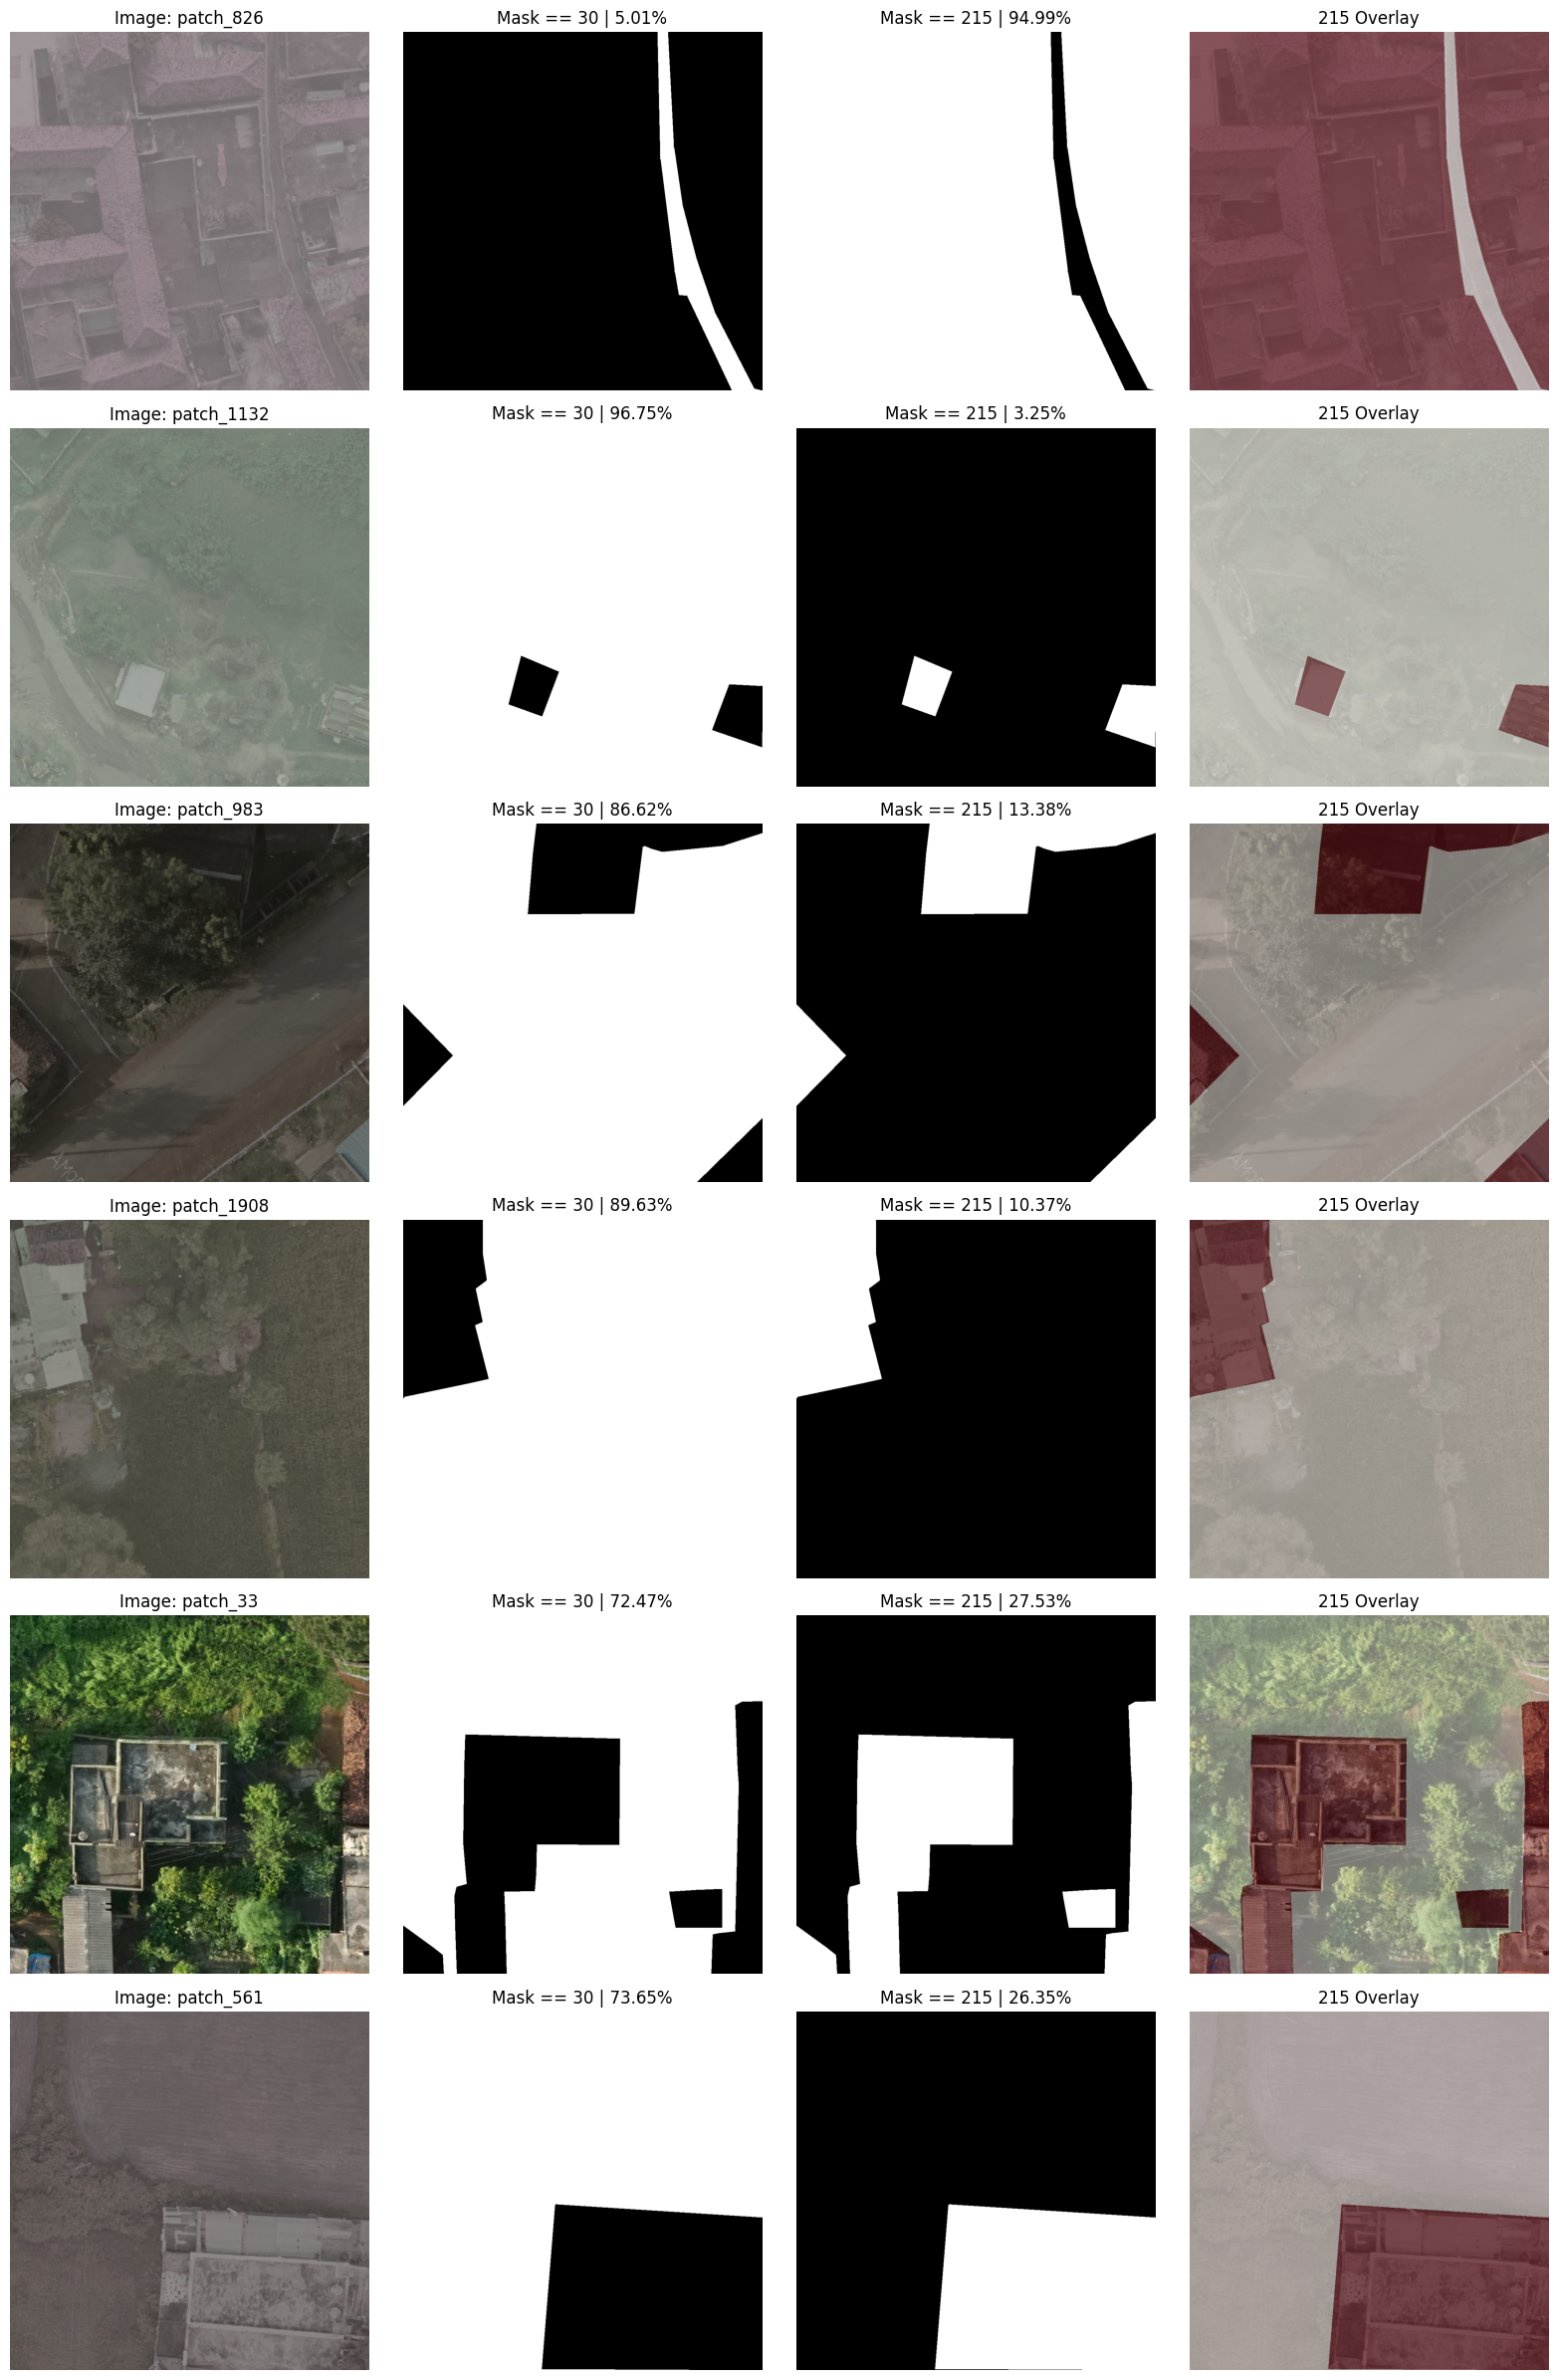

In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

indices = np.random.choice(
    len(df),
    min(6, len(df)),
    replace=False
)

fig, axes = plt.subplots(
    len(indices),
    4,
    figsize=(16, 4 * len(indices))
)

if len(indices) == 1:
    axes = np.expand_dims(axes, 0)

for r, idx in enumerate(indices):
    row = df.iloc[idx]

    image = cv2.imread(row["image"])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(
        row["mask"],
        cv2.IMREAD_GRAYSCALE
    )

    mask_30 = (mask == 30).astype(np.uint8)
    mask_215 = (mask == 215).astype(np.uint8)

    axes[r, 0].imshow(image)
    axes[r, 0].set_title(f"Image: {row['id']}")

    axes[r, 1].imshow(mask_30, cmap="gray")
    axes[r, 1].set_title(
        f"Mask == 30 | {mask_30.mean():.2%}"
    )

    axes[r, 2].imshow(mask_215, cmap="gray")
    axes[r, 2].set_title(
        f"Mask == 215 | {mask_215.mean():.2%}"
    )

    axes[r, 3].imshow(image)
    axes[r, 3].imshow(
        mask_215,
        alpha=0.45,
        cmap="Reds"
    )
    axes[r, 3].set_title("215 Overlay")

    for c in range(4):
        axes[r, c].axis("off")

plt.tight_layout()
plt.show()

In [41]:
sample_ids = min(100, len(df))
all_values = set()

for _, row in df.head(sample_ids).iterrows():
    mask = np.array(Image.open(row["mask"]).convert("L"))
    all_values.update(np.unique(mask).tolist())

print("Unique mask values:", sorted(all_values))

assert 30 in all_values
assert 215 in all_values

positive_pixels = []
positive_ratios = []

for _, row in df.iterrows():
    mask = np.array(Image.open(row["mask"]).convert("L"))
    binary = mask == 215

    positive_pixels.append(int(binary.sum()))
    positive_ratios.append(float(binary.mean()))

df["positive_pixels"] = positive_pixels
df["positive_ratio"] = positive_ratios
df["has_building"] = df["positive_pixels"] > 0

print(f"Mean building ratio   : {df['positive_ratio'].mean():.4%}")
print(f"Median building ratio : {df['positive_ratio'].median():.4%}")
print(f"Images with buildings : {int(df['has_building'].sum())}")
print(f"Empty masks           : {int((~df['has_building']).sum())}")
print(f"Minimum ratio         : {df['positive_ratio'].min():.4%}")
print(f"Maximum ratio         : {df['positive_ratio'].max():.4%}")

display(df["positive_ratio"].describe())

assert df["positive_ratio"].mean() > 0
assert df["positive_ratio"].mean() < 0.95
assert df["has_building"].sum() > 0

Unique mask values: [30, 215]
Mean building ratio   : 30.8334%
Median building ratio : 25.3268%
Images with buildings : 690
Empty masks           : 0
Minimum ratio         : 0.0929%
Maximum ratio         : 95.3005%


count    690.000000
mean       0.308334
std        0.261033
min        0.000929
25%        0.073194
50%        0.253268
75%        0.500541
max        0.953005
Name: positive_ratio, dtype: float64

In [42]:
class SvamitvaDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = cv2.imread(
            row["image"],
            cv2.IMREAD_COLOR
        )

        if image is None:
            raise RuntimeError(
                f"Could not read image: {row['image']}"
            )

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        mask = cv2.imread(
            row["mask"],
            cv2.IMREAD_GRAYSCALE
        )

        if mask is None:
            raise RuntimeError(
                f"Could not read mask: {row['mask']}"
            )

        mask = (mask == 215).astype(np.uint8)

        if self.transform is not None:
            transformed = self.transform(
                image=image,
                mask=mask
            )

            image = transformed["image"]
            mask = transformed["mask"]

        image = image.astype(np.float32) / 255.0

        image = torch.from_numpy(
            image.transpose(2, 0, 1)
        )

        mean = torch.tensor(
            [0.485, 0.456, 0.406],
            dtype=torch.float32
        ).view(3, 1, 1)

        std = torch.tensor(
            [0.229, 0.224, 0.225],
            dtype=torch.float32
        ).view(3, 1, 1)

        image = (image - mean) / std

        mask = torch.from_numpy(
            mask.astype(np.float32)
        ).unsqueeze(0)

        return {
            "image": image,
            "mask": mask,
            "id": row["id"]
        }

print("SvamitvaDataset defined")

SvamitvaDataset defined


In [43]:
train_dataset = SvamitvaDataset(
    dataframe=train_df,
    transform=TRAIN_TRANSFORM_512
)

val_dataset = SvamitvaDataset(
    dataframe=val_df,
    transform=VAL_TRANSFORM_512
)

test_dataset = SvamitvaDataset(
    dataframe=test_df,
    transform=VAL_TRANSFORM_512
)

print("Train samples:", len(train_dataset))
print("Val samples  :", len(val_dataset))
print("Test samples :", len(test_dataset))

Train samples: 129
Val samples  : 16
Test samples : 17


In [44]:
for name, dataset in [
    ("TRAIN", train_dataset),
    ("VAL", val_dataset),
    ("TEST", test_dataset)
]:
    ratios = []

    for i in range(len(dataset)):
        mask = dataset[i]["mask"]
        ratios.append(float(mask.mean()))

    print(
        f"{name} | "
        f"samples={len(dataset)} | "
        f"mean_foreground={np.mean(ratios):.4%} | "
        f"min={np.min(ratios):.4%} | "
        f"max={np.max(ratios):.4%} | "
        f"nonempty={sum(r > 0 for r in ratios)}"
    )

sample = test_dataset[0]

print("Image shape:", sample["image"].shape)
print("Mask shape :", sample["mask"].shape)
print("Mask values:", torch.unique(sample["mask"]).tolist())
print("Foreground:", float(sample["mask"].mean()))

assert set(
    torch.unique(sample["mask"]).tolist()
).issubset({0.0, 1.0})

assert sample["mask"].mean() > 0

TRAIN | samples=129 | mean_foreground=28.6373% | min=0.0000% | max=93.0000% | nonempty=116
VAL | samples=16 | mean_foreground=32.1219% | min=1.4439% | max=95.3072% | nonempty=16
TEST | samples=17 | mean_foreground=33.5367% | min=0.8865% | max=82.4532% | nonempty=17
Image shape: torch.Size([3, 512, 512])
Mask shape : torch.Size([1, 512, 512])
Mask values: [0.0, 1.0]
Foreground: 0.0088653564453125


In [46]:
NUM_WORKERS = 0
BATCH_SIZE_512 = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE_512,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE_512,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE_512,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Train:", len(train_dataset), len(train_loader))
print("Val  :", len(val_dataset), len(val_loader))
print("Test :", len(test_dataset), len(test_loader))

batch = next(iter(train_loader))

print("Image batch:", batch["image"].shape)
print("Mask batch :", batch["mask"].shape)
print("Mask values:", torch.unique(batch["mask"]).tolist())

assert batch["image"].shape == (BATCH_SIZE_512, 3, 512, 512)
assert batch["mask"].shape == (BATCH_SIZE_512, 1, 512, 512)
assert set(torch.unique(batch["mask"]).tolist()).issubset({0.0, 1.0})

print("DataLoader check passed")

Train: 129 32
Val  : 16 4
Test : 17 5
Image batch: torch.Size([4, 3, 512, 512])
Mask batch : torch.Size([4, 1, 512, 512])
Mask values: [0.0, 1.0]
DataLoader check passed


In [47]:
torch.cuda.empty_cache()

model = HRNetW48OCR(
    num_classes=2
).to(DEVICE)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Device              : {DEVICE}")

Unexpected keys (downsamp_modules.0.1.num_batches_tracked, downsamp_modules.1.1.num_batches_tracked, downsamp_modules.2.1.num_batches_tracked, final_layer.1.num_batches_tracked, downsamp_modules.0.0.bias, downsamp_modules.0.0.weight, downsamp_modules.0.1.bias, downsamp_modules.0.1.running_mean, downsamp_modules.0.1.running_var, downsamp_modules.0.1.weight, downsamp_modules.1.0.bias, downsamp_modules.1.0.weight, downsamp_modules.1.1.bias, downsamp_modules.1.1.running_mean, downsamp_modules.1.1.running_var, downsamp_modules.1.1.weight, downsamp_modules.2.0.bias, downsamp_modules.2.0.weight, downsamp_modules.2.1.bias, downsamp_modules.2.1.running_mean, downsamp_modules.2.1.running_var, downsamp_modules.2.1.weight, final_layer.0.bias, final_layer.0.weight, final_layer.1.bias, final_layer.1.running_mean, final_layer.1.running_var, final_layer.1.weight, classifier.bias, classifier.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Backbone feature channels: [64, 128, 256, 512, 1024]
Total fusion channels: 1984
Total parameters    : 80,856,516
Trainable parameters: 80,856,516
Device              : cuda


In [49]:
criterion = combined_loss

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS_512,
    eta_min=1e-6
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP
)

print("Loss function:", criterion.__name__)
print("Optimizer:", optimizer.__class__.__name__)
print("Initial LR:", optimizer.param_groups[0]["lr"])
print("AMP:", USE_AMP)

Loss function: combined_loss
Optimizer: AdamW
Initial LR: 0.0003
AMP: True


In [51]:
criterion = combined_loss

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS_512,
    eta_min=1e-6
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP
)

print("Loss function:", criterion.__name__)
print("Optimizer:", optimizer.__class__.__name__)
print("Initial LR:", optimizer.param_groups[0]["lr"])
print("AMP:", USE_AMP)

Loss function: combined_loss
Optimizer: AdamW
Initial LR: 0.0003
AMP: True


In [52]:
BEST_512 = CHECKPOINT_DIR / "best_512.pth"
LAST_512 = CHECKPOINT_DIR / "last_512.pth"

history = []
best_dice = -1.0

def batch_metrics(preds, target):
    eps = 1e-6

    intersection = (preds * target).sum(dim=(1, 2))
    pred_area = preds.sum(dim=(1, 2))
    target_area = target.sum(dim=(1, 2))

    union = pred_area + target_area - intersection

    dice = (
        2.0 * intersection + eps
    ) / (
        pred_area + target_area + eps
    )

    iou = (
        intersection + eps
    ) / (
        union + eps
    )

    nonempty = target_area > 0

    return dice, iou, nonempty


for epoch in range(1, EPOCHS_512 + 1):

    model.train()

    running_loss = 0.0
    running_ce = 0.0
    running_dice_loss = 0.0
    batch_count = 0

    train_progress = tqdm(
        train_loader,
        total=len(train_loader),
        desc=f"Epoch {epoch}/{EPOCHS_512} [train]"
    )

    for batch in train_progress:

        images = batch["image"].to(
            DEVICE,
            non_blocking=True
        )

        masks = batch["mask"].to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.amp.autocast(
            "cuda",
            enabled=USE_AMP,
            dtype=torch.float16
        ):

            logits, aux_logits = model(images)

            loss, ce, dice_loss_value = combined_loss(
                logits,
                aux_logits,
                masks
            )

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        scaler.step(optimizer)
        scaler.update()

        batch_count += 1

        running_loss += float(
            loss.detach().item()
        )

        running_ce += float(
            ce.detach().item()
        )

        running_dice_loss += float(
            dice_loss_value.detach().item()
        )

        train_progress.set_postfix(
            loss=f"{running_loss / batch_count:.4f}",
            ce=f"{running_ce / batch_count:.4f}",
            dice=f"{running_dice_loss / batch_count:.4f}"
        )

        del images
        del masks
        del logits
        del aux_logits
        del loss
        del ce
        del dice_loss_value

    train_progress.close()

    if batch_count == 0:
        raise RuntimeError(
            "train_loader produced zero batches"
        )

    train_loss = (
        running_loss / batch_count
    )

    train_ce = (
        running_ce / batch_count
    )

    train_dice_loss = (
        running_dice_loss / batch_count
    )

    model.eval()

    val_dice_all = []
    val_iou_all = []

    val_dice_fg = []
    val_iou_fg = []

    val_empty_count = 0
    val_count = 0

    with torch.inference_mode():

        val_progress = tqdm(
            val_loader,
            total=len(val_loader),
            desc=f"Epoch {epoch}/{EPOCHS_512} [val]"
        )

        for batch in val_progress:

            images = batch["image"].to(
                DEVICE,
                non_blocking=True
            )

            masks = batch["mask"].to(
                DEVICE,
                non_blocking=True
            )

            with torch.amp.autocast(
                "cuda",
                enabled=USE_AMP,
                dtype=torch.float16
            ):

                logits, _ = model(images)

            probs = torch.softmax(
                logits.float(),
                dim=1
            )[:, 1]

            preds = (
                probs >= 0.5
            ).float()

            target = masks[:, 0].float()

            dice, iou, nonempty = batch_metrics(
                preds,
                target
            )

            val_dice_all.extend(
                dice.cpu().numpy().tolist()
            )

            val_iou_all.extend(
                iou.cpu().numpy().tolist()
            )

            if nonempty.any():

                val_dice_fg.extend(
                    dice[nonempty]
                    .cpu()
                    .numpy()
                    .tolist()
                )

                val_iou_fg.extend(
                    iou[nonempty]
                    .cpu()
                    .numpy()
                    .tolist()
                )

            val_empty_count += int(
                (~nonempty).sum().item()
            )

            val_count += int(
                target.shape[0]
            )

            del images
            del masks
            del logits
            del probs
            del preds
            del target

    val_progress.close()

    val_dice = float(
        np.mean(val_dice_all)
    ) if val_dice_all else 0.0

    val_iou = float(
        np.mean(val_iou_all)
    ) if val_iou_all else 0.0

    val_dice_fg = float(
        np.mean(val_dice_fg)
    ) if val_dice_fg else 0.0

    val_iou_fg = float(
        np.mean(val_iou_fg)
    ) if val_iou_fg else 0.0

    scheduler.step()

    current_lr = optimizer.param_groups[0]["lr"]

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_ce": train_ce,
        "train_dice_loss": train_dice_loss,
        "val_dice": val_dice,
        "val_iou": val_iou,
        "foreground_dice": val_dice_fg,
        "foreground_iou": val_iou_fg,
        "empty_masks": val_empty_count,
        "validation_samples": val_count,
        "lr": current_lr
    })

    print(
        f"Epoch {epoch}/{EPOCHS_512} | "
        f"train_loss={train_loss:.4f} | "
        f"train_ce={train_ce:.4f} | "
        f"train_dice_loss={train_dice_loss:.4f} | "
        f"val_dice={val_dice:.4f} | "
        f"val_iou={val_iou:.4f} | "
        f"fg_dice={val_dice_fg:.4f} | "
        f"fg_iou={val_iou_fg:.4f} | "
        f"empty_val={val_empty_count}/{val_count} | "
        f"lr={current_lr:.2e}"
    )

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "train_loss": train_loss,
        "train_ce": train_ce,
        "train_dice_loss": train_dice_loss,
        "val_dice": val_dice,
        "val_iou": val_iou,
        "foreground_dice": val_dice_fg,
        "foreground_iou": val_iou_fg,
        "num_params": sum(
            p.numel()
            for p in model.parameters()
        ),
        "num_classes": 2,
        "class_names": [
            "background",
            "building"
        ],
        "mask_background_value": 30,
        "mask_building_value": 215,
        "history": history
    }

    torch.save(
        checkpoint,
        LAST_512
    )

    if val_dice_fg > best_dice:

        best_dice = val_dice_fg

        checkpoint[
            "best_foreground_dice"
        ] = best_dice

        torch.save(
            checkpoint,
            BEST_512
        )

        print(
            f"New best model saved "
            f"(foreground Dice = {best_dice:.4f})"
        )

history_df = pd.DataFrame(history)

history_df.to_csv(
    RESULT_DIR / "training_history_512.csv",
    index=False
)

print(
    f"Training complete | "
    f"Best foreground Dice = {best_dice:.4f}"
)

Epoch 1/25 [train]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1/25 [val]:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1/25 | train_loss=0.7595 | train_ce=0.5754 | train_dice_loss=0.5236 | val_dice=0.8108 | val_iou=0.7098 | fg_dice=0.8108 | fg_iou=0.7098 | empty_val=0/16 | lr=2.99e-04
New best model saved (foreground Dice = 0.8108)


Epoch 2/25 [train]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 2/25 [val]:   0%|          | 0/4 [00:00<?, ?it/s]

...

Epoch 24/25 [val]:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 24/25 | train_loss=0.2953 | train_ce=0.1752 | train_dice_loss=0.2321 | val_dice=0.9209 | val_iou=0.8579 | fg_dice=0.9209 | fg_iou=0.8579 | empty_val=0/16 | lr=2.18e-06


Epoch 25/25 [train]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 25/25 [val]:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 25/25 | train_loss=0.2605 | train_ce=0.1257 | train_dice_loss=0.2338 | val_dice=0.9207 | val_iou=0.8580 | fg_dice=0.9207 | fg_iou=0.8580 | empty_val=0/16 | lr=1.00e-06
Training complete | Best foreground Dice = 0.9270


KeyError: 'fg_dice'

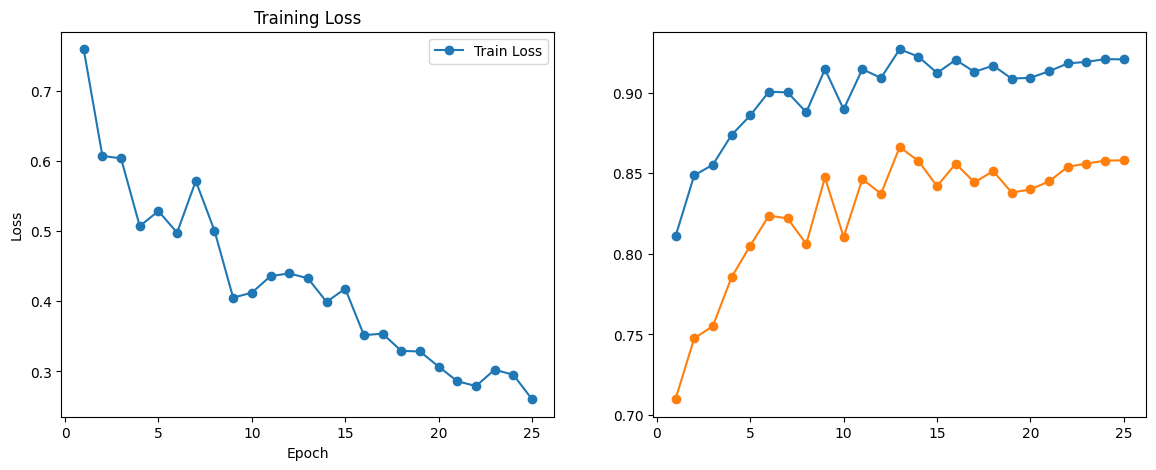

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["val_dice"], marker="o", label="Val Dice")
axes[1].plot(history_df["epoch"], history_df["val_iou"], marker="o", label="Val IoU")
axes[1].plot(history_df["epoch"], history_df["fg_dice"], marker="o", label="Foreground Dice")
axes[1].plot(history_df["epoch"], history_df["fg_iou"], marker="o", label="Foreground IoU")
axes[1].set_title("Validation Segmentation Metrics")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULT_DIR / "training_curves_512.png", dpi=150, bbox_inches="tight")
plt.show()

In [54]:
assert BEST_512.exists(), f"Checkpoint not found: {BEST_512}"

checkpoint = torch.load(BEST_512, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])

best_dice_512 = checkpoint.get("best_dice", checkpoint.get("val_dice", None))
best_iou_512 = checkpoint.get("best_iou", checkpoint.get("val_iou", None))
best_fg_dice_512 = checkpoint.get("fg_dice", best_dice_512)
best_fg_iou_512 = checkpoint.get("fg_iou", best_iou_512)

print("Best 512 checkpoint loaded")
print("Best foreground Dice:", best_fg_dice_512)
print("Best foreground IoU :", best_fg_iou_512)
print("Checkpoint epoch    :", checkpoint.get("epoch"))

Best 512 checkpoint loaded
Best foreground Dice: 0.9270319528877735
Best foreground IoU : 0.8662465661764145
Checkpoint epoch    : 13


In [55]:
model.eval()

dice_scores = []
iou_scores = []
precision_scores = []
recall_scores = []
accuracy_scores = []

with torch.inference_mode():
    for batch in tqdm(val_loader, desc="Validating 512"):
        images = batch["image"].to(DEVICE, non_blocking=True)
        masks = batch["mask"].to(DEVICE, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=USE_AMP, dtype=torch.float16):
            logits, aux_logits = model(images)

        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = (probs >= 0.5).float()
        target = masks[:, 0].float()

        intersection = (preds * target).sum(dim=(1, 2))
        pred_area = preds.sum(dim=(1, 2))
        target_area = target.sum(dim=(1, 2))
        union = pred_area + target_area - intersection

        dice = (2.0 * intersection + 1e-6) / (pred_area + target_area + 1e-6)
        iou = (intersection + 1e-6) / (union + 1e-6)

        tp = intersection
        fp = (preds * (1.0 - target)).sum(dim=(1, 2))
        fn = ((1.0 - preds) * target).sum(dim=(1, 2))

        precision = (tp + 1e-6) / (tp + fp + 1e-6)
        recall = (tp + 1e-6) / (tp + fn + 1e-6)
        accuracy = (preds == target).float().mean(dim=(1, 2))

        dice_scores.extend(dice.cpu().numpy())
        iou_scores.extend(iou.cpu().numpy())
        precision_scores.extend(precision.cpu().numpy())
        recall_scores.extend(recall.cpu().numpy())
        accuracy_scores.extend(accuracy.cpu().numpy())

print("512 FOREGROUND BUILDING VALIDATION RESULTS")
print(f"Dice      : {np.mean(dice_scores):.4f}")
print(f"IoU       : {np.mean(iou_scores):.4f}")
print(f"Precision : {np.mean(precision_scores):.4f}")
print(f"Recall    : {np.mean(recall_scores):.4f}")
print(f"Pixel Acc : {np.mean(accuracy_scores):.4f}")

Validating 512:   0%|          | 0/4 [00:00<?, ?it/s]

512 FOREGROUND BUILDING VALIDATION RESULTS
Dice      : 0.9270
IoU       : 0.8662
Precision : 0.9150
Recall    : 0.9448
Pixel Acc : 0.9546


In [56]:
model.eval()

all_probs = []
all_targets = []

with torch.inference_mode():
    for batch in tqdm(val_loader, desc="Collecting validation probabilities"):
        images = batch["image"].to(DEVICE, non_blocking=True)
        masks = batch["mask"]

        with torch.amp.autocast("cuda", enabled=USE_AMP, dtype=torch.float16):
            logits, _ = model(images)

        probs = torch.softmax(logits, dim=1)[:, 1]

        all_probs.append(probs.float().cpu())
        all_targets.append(masks[:, 0].float())

all_probs = torch.cat(all_probs)
all_targets = torch.cat(all_targets)

threshold_results = []

for threshold in np.arange(0.20, 0.81, 0.02):
    preds = (all_probs >= threshold).float()

    intersection = (preds * all_targets).sum(dim=(1, 2))
    pred_area = preds.sum(dim=(1, 2))
    target_area = all_targets.sum(dim=(1, 2))
    union = pred_area + target_area - intersection

    dice = ((2.0 * intersection + 1e-6) / (pred_area + target_area + 1e-6)).mean().item()
    iou = ((intersection + 1e-6) / (union + 1e-6)).mean().item()

    threshold_results.append((float(threshold), dice, iou))

best_threshold, best_dice_thr, best_iou_thr = max(
    threshold_results,
    key=lambda x: x[1]
)

threshold_df = pd.DataFrame(
    threshold_results,
    columns=["threshold", "dice", "iou"]
)

threshold_df.to_csv(
    RESULT_DIR / "threshold_optimization_512.csv",
    index=False
)

print("512 FOREGROUND BUILDING THRESHOLD OPTIMIZATION")
print(f"Best threshold    : {best_threshold:.2f}")
print(f"Best Dice         : {best_dice_thr:.4f}")
print(f"Corresponding IoU : {best_iou_thr:.4f}")

512 FOREGROUND BUILDING THRESHOLD OPTIMIZATION
Best threshold    : 0.62
Best Dice         : 0.9281
Corresponding IoU : 0.8681


In [57]:
threshold_file = RESULT_DIR / "optimal_threshold_512.json"

with open(threshold_file, "w") as f:
    json.dump(
        {
            "stage": "512",
            "threshold": float(best_threshold),
            "dice": float(best_dice_thr),
            "iou": float(best_iou_thr)
        },
        f,
        indent=2
    )

print("Saved:", threshold_file)

Saved: /kaggle/working/SVAMITVA_HRNetW48_OCR/results/optimal_threshold_512.json


In [59]:
import shutil
import json
from pathlib import Path

FINAL_DIR = Path("/kaggle/working/SVAMITVA_HRNetW48_OCR_512")
FINAL_DIR.mkdir(parents=True, exist_ok=True)

best_checkpoint = torch.load(
    BEST_512,
    map_location="cpu",
    weights_only=False
)

model.load_state_dict(best_checkpoint["model_state_dict"])

torch.save(
    best_checkpoint,
    FINAL_DIR / "best_512.pth"
)

torch.save(
    best_checkpoint["model_state_dict"],
    FINAL_DIR / "model_state_dict_512.pth"
)

if "history_df" in globals():
    history_df.to_csv(
        FINAL_DIR / "training_history_512.csv",
        index=False
    )

threshold_value = float(
    best_threshold
) if "best_threshold" in globals() else 0.5

best_foreground_dice = float(
    best_checkpoint.get(
        "best_foreground_dice",
        best_checkpoint.get(
            "fg_dice",
            best_checkpoint.get(
                "best_dice",
                best_checkpoint.get("val_dice", 0.0)
            )
        )
    )
)

best_foreground_iou = float(
    best_checkpoint.get(
        "best_foreground_iou",
        best_checkpoint.get(
            "fg_iou",
            best_checkpoint.get(
                "best_iou",
                best_checkpoint.get("val_iou", 0.0)
            )
        )
    )
)

config = {
    "model": "HRNet-W48 OCR",
    "input_size": 512,
    "num_classes": 2,
    "class_names": ["background", "building"],
    "mask_encoding": {
        "background": 30,
        "building": 215
    },
    "best_checkpoint": "best_512.pth",
    "model_state_dict": "model_state_dict_512.pth",
    "best_epoch": int(best_checkpoint.get("epoch", 0)),
    "best_foreground_dice": best_foreground_dice,
    "best_foreground_iou": best_foreground_iou,
    "threshold": threshold_value
}

with open(FINAL_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=2)

files_to_copy = [
    "test_results_512.json",
    "optimal_threshold_512.json",
    "training_history_512.csv"
]

for filename in files_to_copy:
    source = RESULT_DIR / filename
    destination = FINAL_DIR / filename

    if source.exists() and source.resolve() != destination.resolve():
        shutil.copy2(source, destination)

archive = shutil.make_archive(
    "/kaggle/working/Final_SVAMITVA_HRNetW48_OCR_512_final",
    "zip",
    root_dir=FINAL_DIR
)

print("Model saved:", FINAL_DIR)
print("Archive:", archive)
print("Best epoch:", config["best_epoch"])
print("Best foreground Dice:", config["best_foreground_dice"])
print("Best foreground IoU:", config["best_foreground_iou"])
print("Optimal threshold:", config["threshold"])
print("Mask encoding: 30 = background, 215 = building")

Model saved: /kaggle/working/SVAMITVA_HRNetW48_OCR_512
Archive: /kaggle/working/Final_SVAMITVA_HRNetW48_OCR_512_final.zip
Best epoch: 13
Best foreground Dice: 0.9270319528877735
Best foreground IoU: 0.8662465661764145
Optimal threshold: 0.6199999999999999
Mask encoding: 30 = background, 215 = building


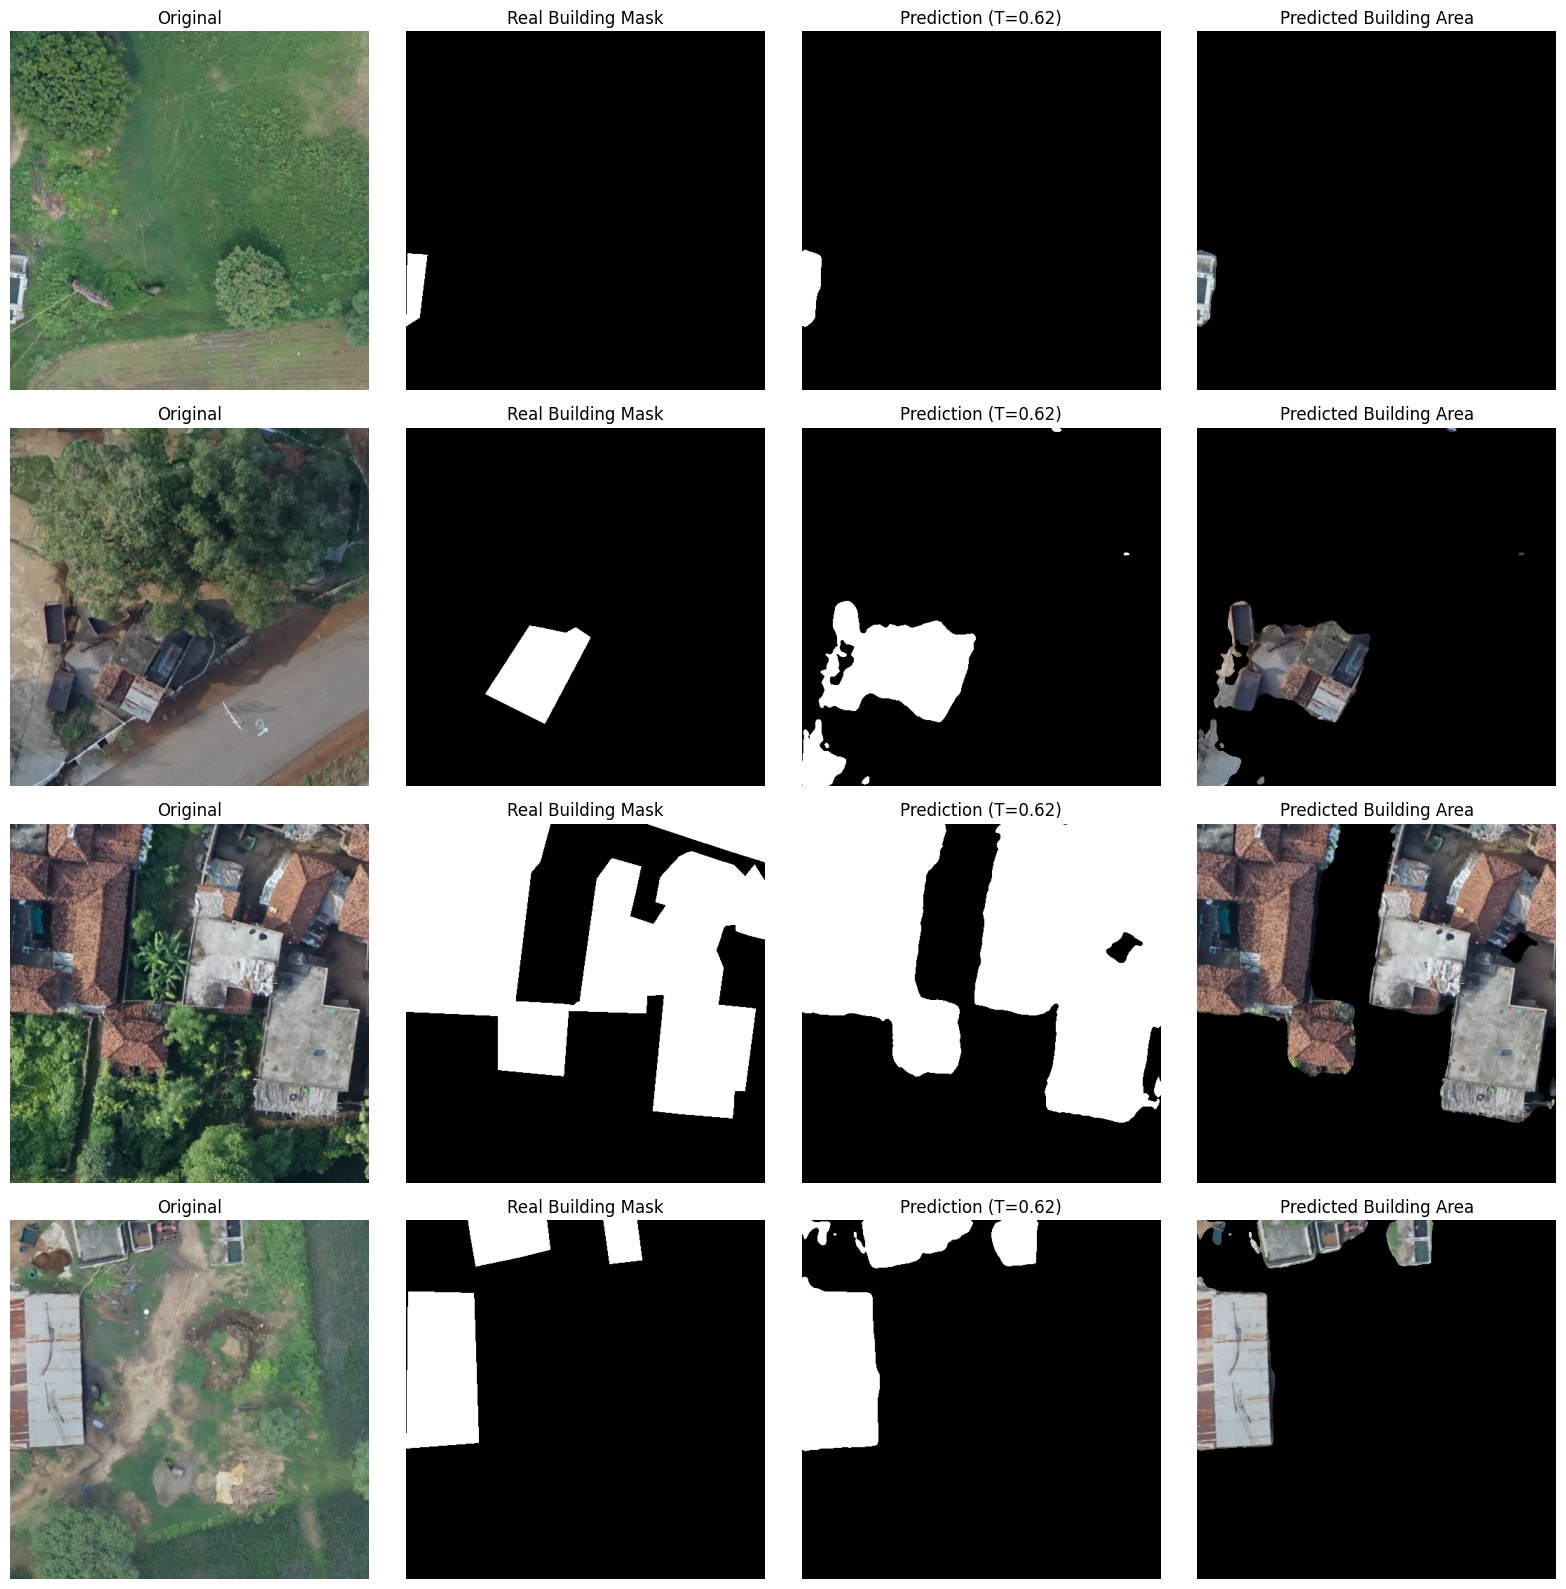

Prediction threshold: 0.6199999999999999
Saved: /kaggle/working/SVAMITVA_HRNetW48_OCR/results/prediction_vs_real_512.png


In [60]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import json

checkpoint = torch.load(
    BEST_512,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()

threshold_file = RESULT_DIR / "optimal_threshold_512.json"

if threshold_file.exists():
    with open(threshold_file, "r") as f:
        threshold_data = json.load(f)
    threshold = float(threshold_data["threshold"])
else:
    threshold = float(
        best_threshold if "best_threshold" in globals() else 0.5
    )

batch = next(iter(test_loader))

images = batch["image"].to(DEVICE)
masks = batch["mask"].to(DEVICE)

with torch.inference_mode():
    with torch.amp.autocast(
        "cuda",
        enabled=USE_AMP,
        dtype=torch.float16
    ):
        logits, _ = model(images)

probs = torch.softmax(
    logits.float(),
    dim=1
)[:, 1]

predictions = (probs >= threshold).float()

num_show = min(4, images.shape[0])

fig, axes = plt.subplots(
    num_show,
    4,
    figsize=(16, 4 * num_show)
)

if num_show == 1:
    axes = np.expand_dims(axes, axis=0)

for i in range(num_show):
    image = images[i].detach().cpu().float()
    image = image.permute(1, 2, 0).numpy()

    image = image - image.min()
    image = image / (image.max() + 1e-8)

    real_mask = masks[i, 0].detach().cpu().numpy()
    pred_mask = predictions[i].detach().cpu().numpy()

    masked_image = image * pred_mask[..., None]

    axes[i, 0].imshow(image)
    axes[i, 0].set_title("Original")

    axes[i, 1].imshow(real_mask, cmap="gray")
    axes[i, 1].set_title("Real Building Mask")

    axes[i, 2].imshow(pred_mask, cmap="gray")
    axes[i, 2].set_title(f"Prediction (T={threshold:.2f})")

    axes[i, 3].imshow(masked_image)
    axes[i, 3].set_title("Predicted Building Area")

    for j in range(4):
        axes[i, j].axis("off")

plt.tight_layout()

prediction_visualization = RESULT_DIR / "prediction_vs_real_512.png"

plt.savefig(
    prediction_visualization,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Prediction threshold:", threshold)
print("Saved:", prediction_visualization)

In [37]:
import numpy as np
import torch
from collections import Counter

print("TEST DATASET SIZE:", len(test_dataset))

for i in range(min(10, len(test_dataset))):
    sample = test_dataset[i]

    image = sample["image"]
    mask = sample["mask"]

    print(
        f"\nSample {i} | ID: {sample.get('id', 'N/A')}"
    )
    print(
        "Image:",
        tuple(image.shape),
        image.dtype,
        float(image.min()),
        float(image.max())
    )
    print(
        "Mask:",
        tuple(mask.shape),
        mask.dtype,
        float(mask.min()),
        float(mask.max())
    )
    print(
        "Mask unique:",
        torch.unique(mask)[:20].cpu().numpy()
    )
    print(
        "Foreground pixels:",
        int((mask > 0).sum().item())
    )
    print(
        "Foreground ratio:",
        float((mask > 0).float().mean().item())
    )

TEST DATASET SIZE: 17

Sample 0 | ID: patch_460
Image: (3, 512, 512) torch.float32 -1.7754088640213013 2.3437039852142334
Mask: (1, 512, 512) torch.float32 1.0 1.0
Mask unique: [1.]
Foreground pixels: 262144
Foreground ratio: 1.0

Sample 1 | ID: patch_143
Image: (3, 512, 512) torch.float32 -1.9295316934585571 2.483137607574463
Mask: (1, 512, 512) torch.float32 1.0 1.0
Mask unique: [1.]
Foreground pixels: 262144
Foreground ratio: 1.0

Sample 2 | ID: patch_121
Image: (3, 512, 512) torch.float32 -2.1179039478302 2.640000104904175
Mask: (1, 512, 512) torch.float32 1.0 1.0
Mask unique: [1.]
Foreground pixels: 262144
Foreground ratio: 1.0

Sample 3 | ID: patch_232
Image: (3, 512, 512) torch.float32 -2.1179039478302 2.430849552154541
Mask: (1, 512, 512) torch.float32 1.0 1.0
Mask unique: [1.]
Foreground pixels: 262144
Foreground ratio: 1.0

Sample 4 | ID: patch_273
Image: (3, 512, 512) torch.float32 -1.7754088640213013 2.6225709915161133
Mask: (1, 512, 512) torch.float32 1.0 1.0
Mask unique: 